# Introducción al Tratamiento de Series Temporales
En este notebook aprenderás los conceptos fundamentales de las series temporales, cómo se estructuran, cómo se visualizan y cómo se procesan. Incluiremos teoría explicada con claridad para quienes nunca han trabajado con este tipo de datos, junto con ejemplos prácticos en Python.

## ¿Qué es una serie temporal?
Una **serie temporal** es un conjunto de observaciones ordenadas en el tiempo. Cada dato tiene asociado un instante temporal. Algunos ejemplos comunes son:
* Temperatura diaria
* Ventas mensuales de una empresa
* Señales biométricas (ritmo cardíaco, acelerometría, etc.)
* Tráfico en una web por horas

Las series temporales suelen presentar patrones como:
* **Tendencia**: evolución creciente o decreciente a largo plazo.
* **Estacionalidad**: fluctuaciones periódicas.
* **Ciclo**: movimientos amplios relacionados con factores externos.
* **Ruido**: variabilidad aleatoria sin patrón visible.

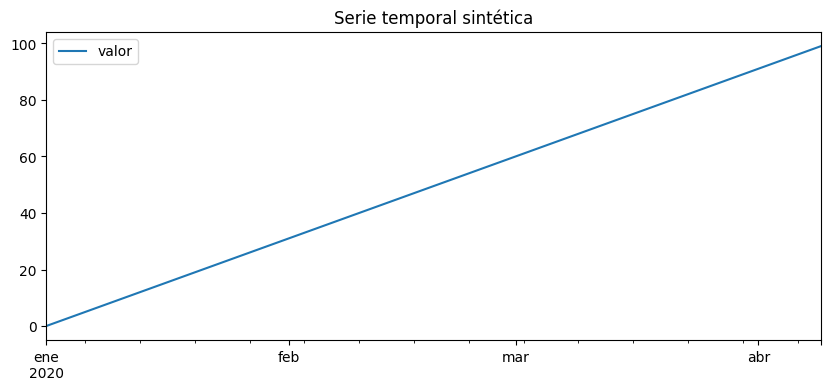

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Creamos una serie temporal sintética
fechas = pd.date_range(start='2020-01-01', periods=100, freq='D')
valores = pd.Series(range(100))
valores.index = fechas
serie = pd.DataFrame({'valor': valores})



serie.plot(figsize=(10,4))
plt.title('Serie temporal sintética')
plt.show()

In [5]:
serie

,valor
2020-01-01,0
2020-01-02,1
2020-01-03,2
2020-01-04,3
2020-01-05,4
...,...
2020-04-05,95
2020-04-06,96
2020-04-07,97
2020-04-08,98


## Descomposición de series temporales
Descomponer una serie temporal consiste en separar sus componentes: tendencia, estacionalidad y residuo. Python permite hacerlo fácilmente con `statsmodels`.

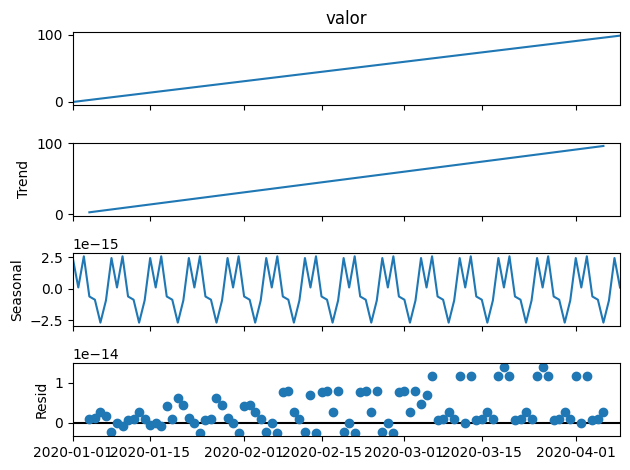

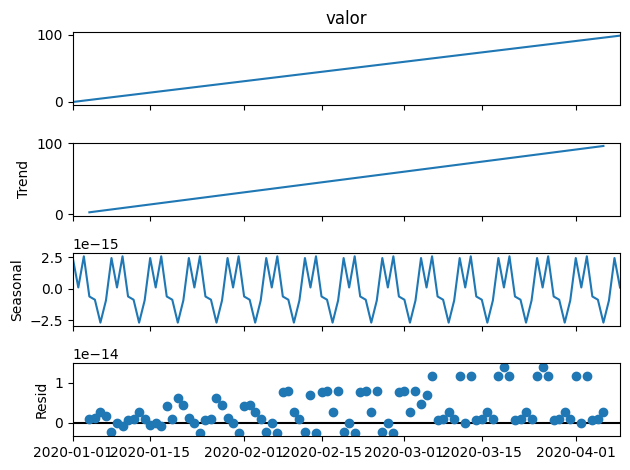

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomp = seasonal_decompose(serie['valor'], model='additive', period=7)
descomp.plot()

## Suavizado y medias móviles
El suavizado permite reducir el ruido y observar mejor la tendencia. La técnica más simple es la **media móvil**.

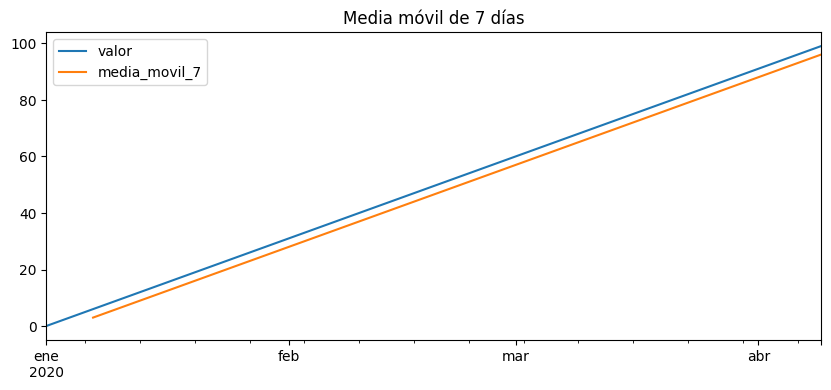

In [7]:
serie['media_movil_7'] = serie['valor'].rolling(window=7).mean()
serie[['valor','media_movil_7']].plot(figsize=(10,4))
plt.title('Media móvil de 7 días')
plt.show()

## Modelos ARIMA
Los modelos ARIMA (Autoregressive Integrated Moving Average) son de los más utilizados para predicciones a corto plazo. Requieren que la serie sea estacionaria.

### Estacionalidad
Una serie es estacionaria si su media y varianza no cambian con el tiempo. Para ello se suele aplicar la **diferenciación**.

<Axes: title={'center': 'Serie diferenciada'}>

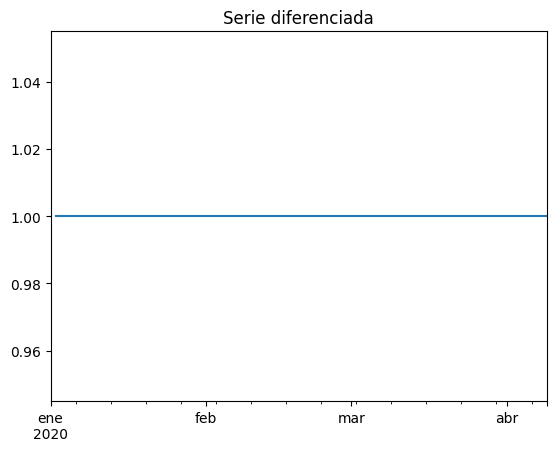

In [8]:
serie['diff'] = serie['valor'].diff()
serie['diff'].plot(title='Serie diferenciada')

### Ajustar un modelo ARIMA
Usaremos `statsmodels` para entrenar un modelo ARIMA simple.

In [9]:
from statsmodels.tsa.arima.model import ARIMA

modelo = ARIMA(serie['valor'], order=(1,1,1))
ajuste = modelo.fit()
print(ajuste.summary())

/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                  valor   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 509.035
Date:                lun, 24 nov 2025   AIC                          -1012.069
Time:                        18:13:44   BIC                          -1004.284
Sample:                    01-01-2020   HQIC                         -1008.919
                         - 04-09-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997   6.81e-05   1.47e+04      0.000       1.000       1.000
ma.L1          0.9988   8.32e-10    1.2e+09      0.000       0.999       0.999
sigma2      1.863e-06   3.71e-07      5.027      0.0

/home/jordi/Documentos/Ribera/Curso_25_26/CEDAPY/REPOS/CEDAPY_25_26/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Predicción
Una vez entrenado el modelo, podemos generar predicciones.

In [10]:
pred = ajuste.forecast(steps=10)
print(pred)

2020-04-10     99.999830
2020-04-11    100.999319
2020-04-12    101.998469
2020-04-13    102.997278
2020-04-14    103.995748
2020-04-15    104.993878
2020-04-16    105.991669
2020-04-17    106.989120
2020-04-18    107.986232
2020-04-19    108.983005
Freq: D, Name: predicted_mean, dtype: float64
